In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import re
import seaborn as sns 

## Import Dataset

In [2]:
df=pd.read_csv("laptop_data.csv")

In [3]:
df.shape

(1303, 12)

In [4]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [5]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [6]:
df.shape

(1303, 12)

In [7]:
df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [9]:
df.describe()

,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [10]:
df.sample(5)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1166,1166,Lenovo,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg,74059.20
582,582,HP,Notebook,13.3,Full HD 1920x1080,Intel Core i3 7100U 2.4GHz,4GB,128GB SSD,Intel HD Graphics 620,Windows 10,1.49kg,38308.32
1051,1051,HP,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 940MX,Windows 10,1.91kg,52161.12
861,861,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7300U 2.6GHz,8GB,256GB SSD,AMD Radeon R7 M465,Windows 10,1.84kg,71874.72
1173,1173,Lenovo,Notebook,15.6,1366x768,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,No OS,2.1kg,21205.44


# Data Cleaning and visualization

## Drop the column 'Unnamed: 0'

In [11]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [12]:
df['Price'] = df['Price'].apply(round)

# column: "Compnay"

In [13]:
df['Company'].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

<Axes: xlabel='Company'>

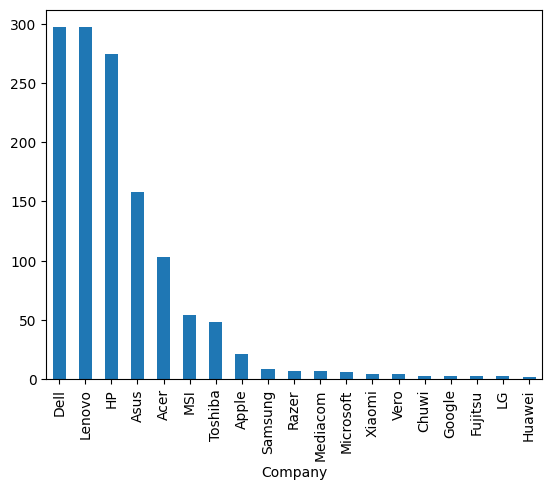

In [14]:
df['Company'].value_counts().plot(kind='bar')


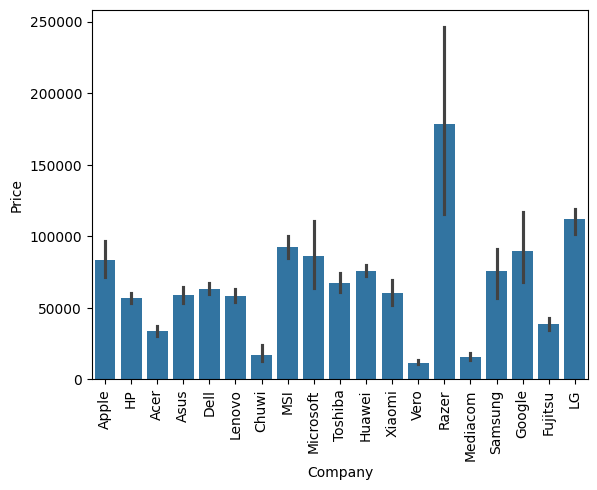

In [15]:
sns.barplot(df,x=df['Company'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

In [16]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71379
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47896
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96096


## column: 'TypeName'

In [17]:
df['TypeName'].value_counts()

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

<Axes: xlabel='TypeName'>

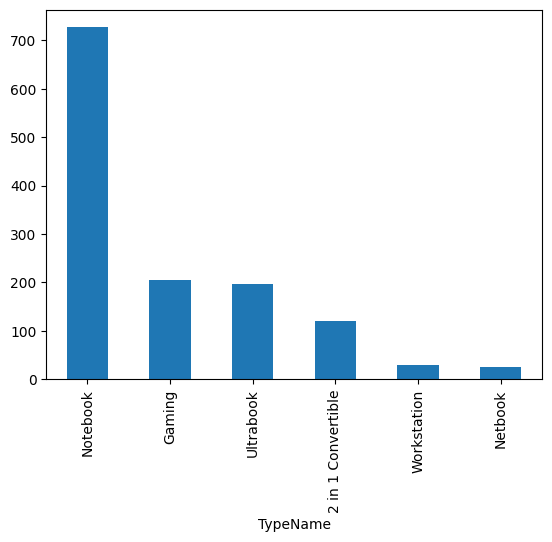

In [18]:
df['TypeName'].value_counts().plot(kind='bar')

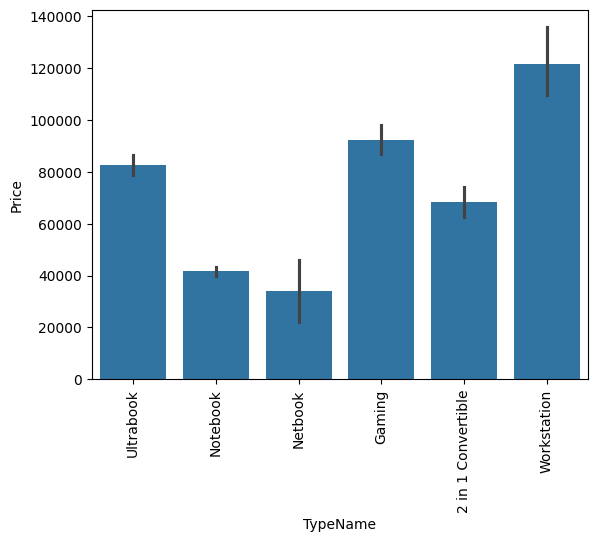

In [19]:
sns.barplot(df,x=df['TypeName'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

In [20]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71379
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47896


## column: 'Inches'

<Axes: xlabel='Inches'>

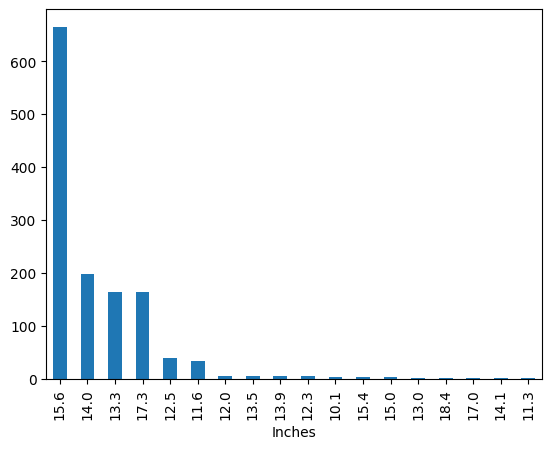

In [21]:
df['Inches'].value_counts().plot(kind='bar')

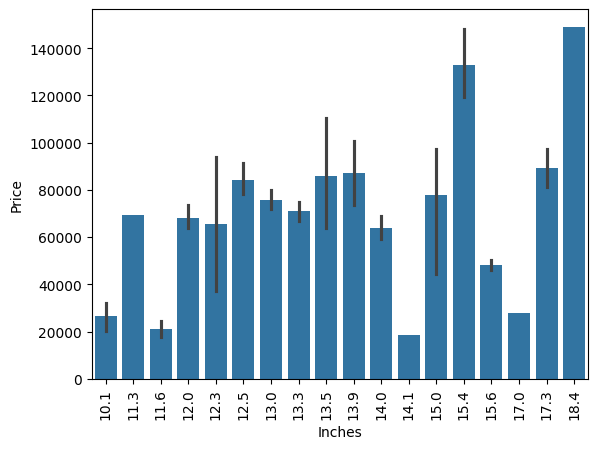

In [22]:
sns.barplot(df,x=df['Inches'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

In [23]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71379
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47896


## column "ScreenResolution"

In [24]:
df['ScreenResolution'].sample(10)

430                               1366x768
1155                     Full HD 1920x1080
1189           IPS Panel Full HD 1920x1080
1069    IPS Panel Retina Display 2304x1440
65                       Full HD 1920x1080
9              IPS Panel Full HD 1920x1080
550                      Full HD 1920x1080
1005                              1366x768
705                      Full HD 1920x1080
1008                     Full HD 1920x1080
Name: ScreenResolution, dtype: object

Extract: IPS Pnael,
Full HD,
TouchScreen,
Ultra,
Quad HD+,
Retina,
Retina Display,
resolutions

In [25]:
df['IPS']=df['ScreenResolution'].apply(lambda x:1 if "IPS" in x else 0)

In [26]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71379,1
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47896,0


In [27]:
df['IPS'].value_counts()

IPS
0    938
1    365
Name: count, dtype: int64

<Axes: xlabel='IPS'>

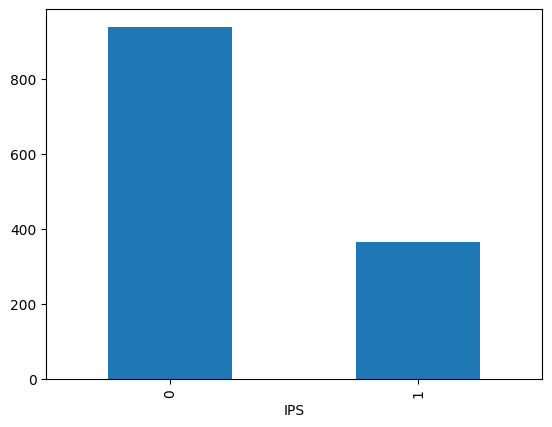

In [28]:
df['IPS'].value_counts().plot(kind='bar')

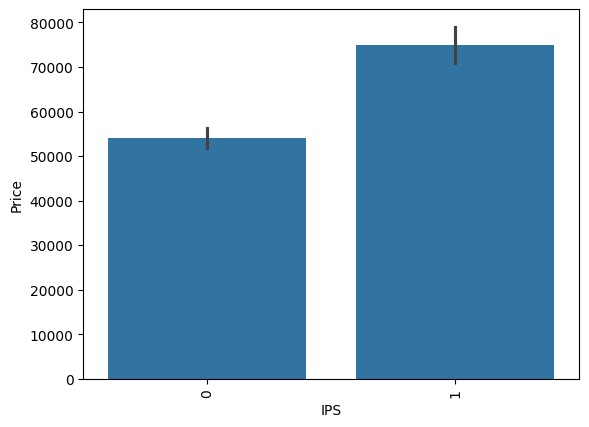

In [29]:
sns.barplot(df,x=df['IPS'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

In [30]:
df['Full HD']=df['ScreenResolution'].apply(lambda x:1 if 'Full' in x else 0)

<Axes: xlabel='Full HD'>

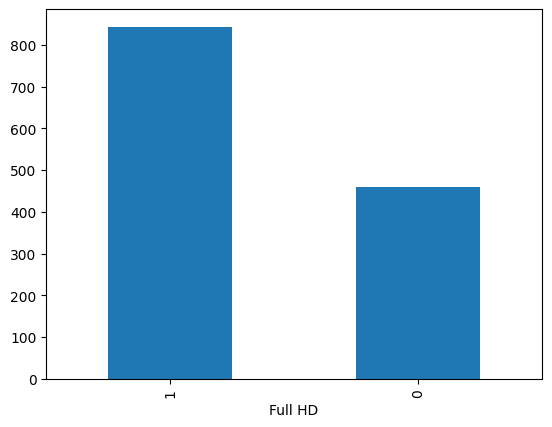

In [31]:
df['Full HD'].value_counts().plot(kind='bar')

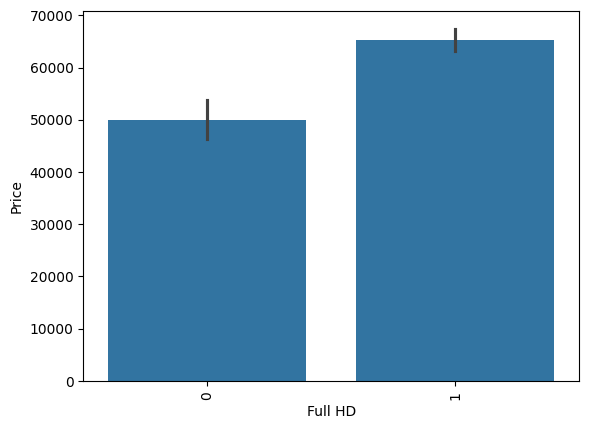

In [32]:
sns.barplot(df,x=df['Full HD'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

In [33]:
df['TouchScreen']=df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [34]:
df['TouchScreen'].value_counts()

TouchScreen
0    1111
1     192
Name: count, dtype: int64

<Axes: xlabel='TouchScreen'>

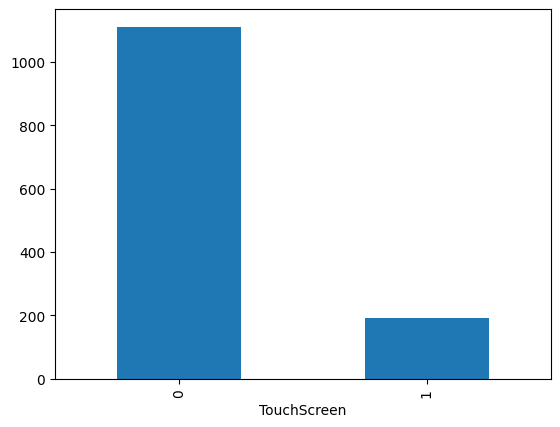

In [35]:
df['TouchScreen'].value_counts().plot(kind='bar')

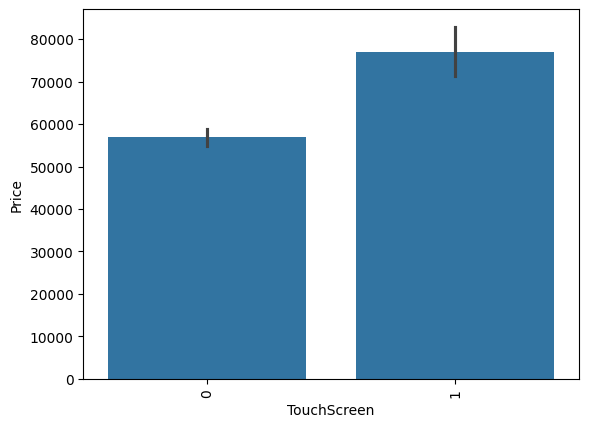

In [36]:
sns.barplot(df,x=df['TouchScreen'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

In [37]:
df['Ultra HD']=df['ScreenResolution'].apply(lambda x:1 if 'Ultra' in x else 0)

<Axes: xlabel='Ultra HD'>

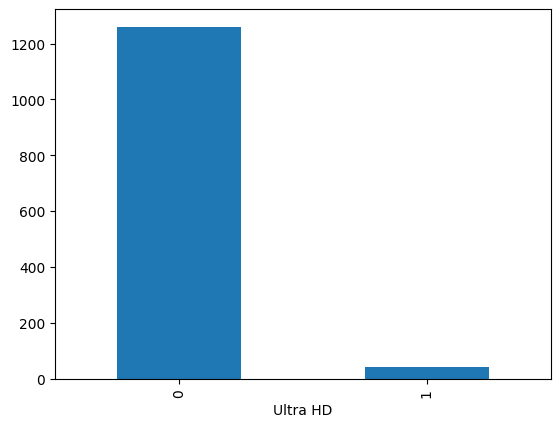

In [38]:
df['Ultra HD'].value_counts().plot(kind='bar')

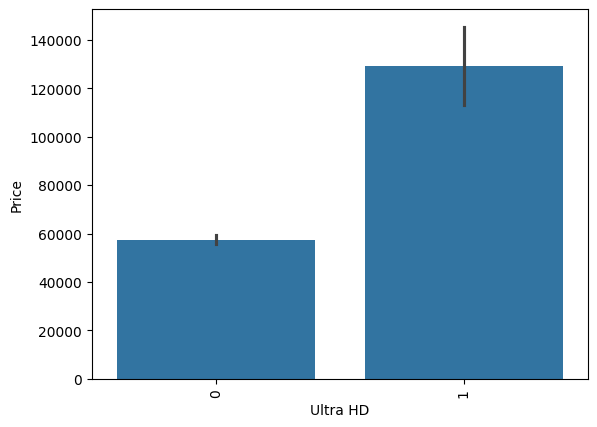

In [39]:
sns.barplot(df,x=df['Ultra HD'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

In [40]:
df['Retina Display']=df['ScreenResolution'].apply(lambda x:1 if 'Retina' in x else 0)

In [41]:
df['Retina Display'].value_counts()

Retina Display
0    1286
1      17
Name: count, dtype: int64

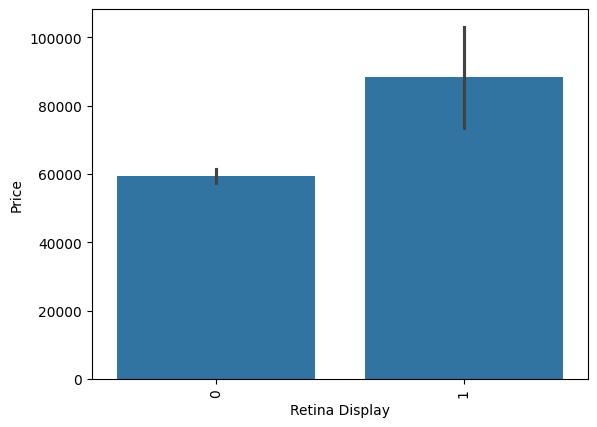

In [42]:
sns.barplot(df,x=df['Retina Display'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

In [43]:
df['ScreenResolution'].sample(5)

275                        1366x768
1051    IPS Panel Full HD 1920x1080
1195    IPS Panel Full HD 1920x1080
387               Full HD 1920x1080
164                        1366x768
Name: ScreenResolution, dtype: object

In [44]:
temp_df=df['ScreenResolution'].str.split('x',expand=True)

In [45]:
temp_df[0]

0               IPS Panel Retina Display 2560
1                                        1440
2                                Full HD 1920
3               IPS Panel Retina Display 2880
4               IPS Panel Retina Display 2560
                        ...                  
1298     IPS Panel Full HD / Touchscreen 1920
1299    IPS Panel Quad HD+ / Touchscreen 3200
1300                                     1366
1301                                     1366
1302                                     1366
Name: 0, Length: 1303, dtype: object

In [46]:
df['X_Resolution']=temp_df[0].str.extract(r'(\d{3,4})')

In [47]:
df['Y_resolution']=temp_df[1]

<Axes: xlabel='X_Resolution'>

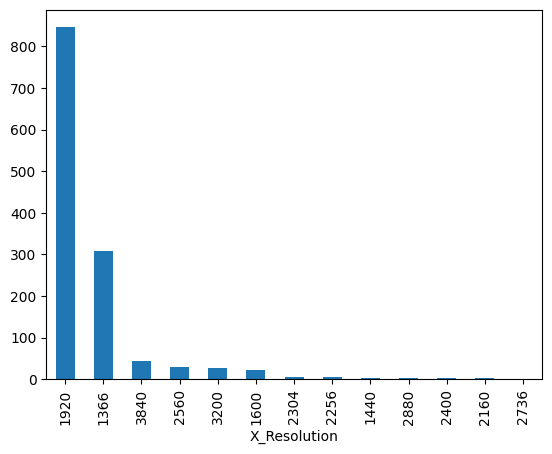

In [48]:
df['X_Resolution'].value_counts().plot(kind='bar')

<Axes: xlabel='Y_resolution'>

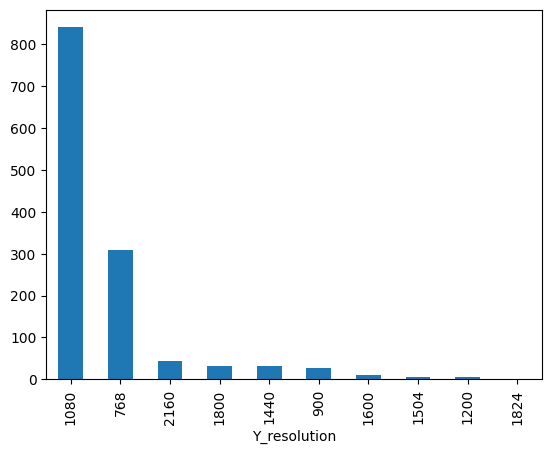

In [49]:
df['Y_resolution'].value_counts().plot(kind='bar')

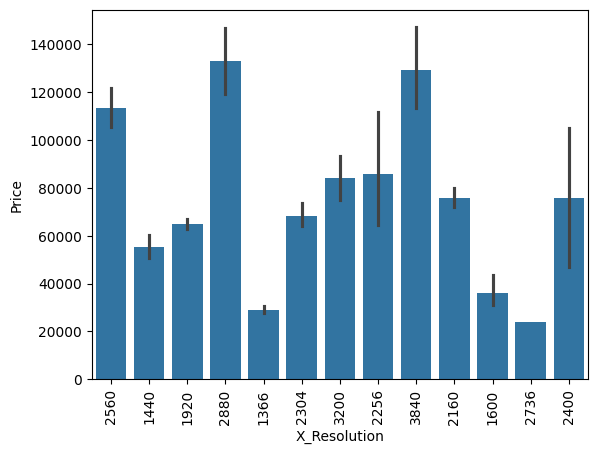

In [50]:
sns.barplot(df,x=df['X_Resolution'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

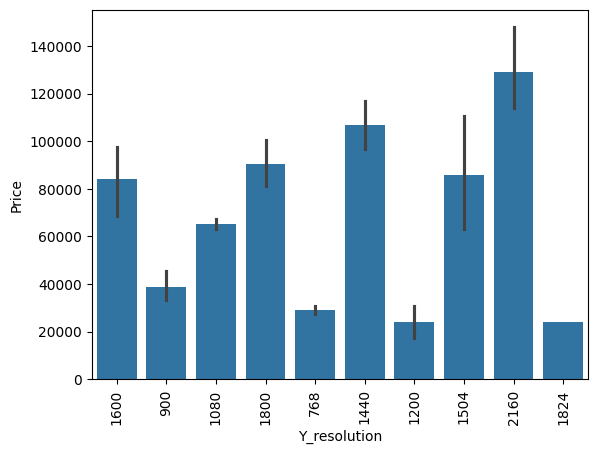

In [51]:
sns.barplot(df,x=df['Y_resolution'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

To calculate PPI (Pixels Per Inch), divide the diagonal resolution (in pixels) by the diagonal screen size (in inches).

In [52]:
df['X_Resolution']=df['X_Resolution'].astype(float)
df['Y_resolution']=df['Y_resolution'].astype(float)
df['PPI']=((((df['X_Resolution'])**2+(df['Y_resolution'])**2)**0.5)/df['Inches']).astype(float)

In [133]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Full HD,TouchScreen,Ultra HD,Retina Display,X_Resolution,Y_resolution,PPI,SSD,HDD,Flash Storage,Hybrid Storage,new cpu,cpu brand,new gpu,OS
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71379,1,0,0,0,1,2560.0,1600.0,226.983005,128,0,0,0,Intel Core i5,Intel Core i5,Intel,Mac
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47896,0,0,0,0,0,1440.0,900.0,127.677940,0,0,128,0,Intel Core i5,Intel Core i5,Intel,Mac


## Column "Ram"

In [54]:
df['Ram'].head()

0     8GB
1     8GB
2     8GB
3    16GB
4     8GB
Name: Ram, dtype: object

In [55]:
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)

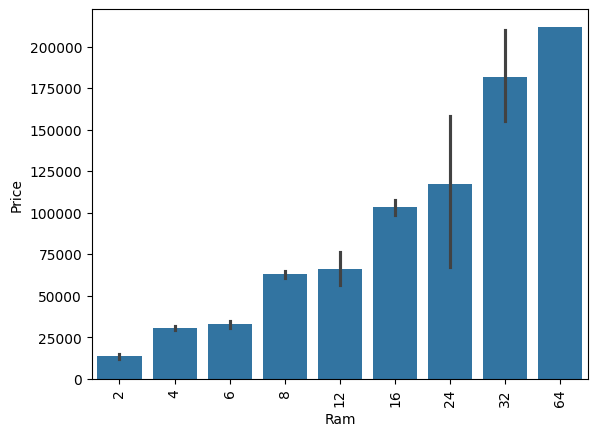

In [56]:
sns.barplot(df,x=df['Ram'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

In [57]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Full HD,TouchScreen,Ultra HD,Retina Display,X_Resolution,Y_resolution,PPI
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71379,1,0,0,0,1,2560.0,1600.0,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47896,0,0,0,0,0,1440.0,900.0,127.677940


## Column 'Memory'

In [58]:
df['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
512GB SSD +  1TB HDD              14
1TB SSD                           14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD         

In [59]:
df['Memory'].sample(10)

225                256GB SSD
813                  1TB HDD
817       16GB Flash Storage
1121               256GB SSD
438                512GB SSD
385                512GB SSD
197                512GB SSD
1197    512GB SSD +  1TB HDD
615     128GB SSD +  1TB HDD
875                256GB SSD
Name: Memory, dtype: object

Make a column for HDD,SSD,Flash Storage, Hybrid 

In [60]:
# Convert TB to GB
def TBconverter(x):
    match = re.search(r'(\d+\.?\d*)\s*TB', x)
    if match:
        tb_value=float(match.group(1))
        gb_value=int(tb_value*1000)
        return x.replace(match.group(0),f'{gb_value}GB')
    return x

        
df['Memory']=df['Memory'].apply(TBconverter)

In [61]:
def extract_SSD(x):
    ssd_match= re.findall(r'(\d+)\s*GB\s*SSD', str(x))    
    if ssd_match:
        return sum([int(match) for match in ssd_match])
    else:
        return 0
df['SSD']=df['Memory'].apply(extract_SSD)


In [62]:
def extract_HDD(x):
    hdd_match= re.findall(r'(\d+)\s*GB\s*HDD', str(x))    
    if hdd_match:
        return sum([int(match) for match in hdd_match])
    else:
        return 0

df['HDD']=df['Memory'].apply(extract_HDD)

In [63]:
def extract_flash(x):
    flash_match=re.findall(r'(\d+)\s*GB\s*Flash\s*Storage',str(x))
    if flash_match:
        return sum([int(match) for match in flash_match])
    else:
        return 0
df['Flash Storage']=df['Memory'].apply(extract_flash)


In [64]:
def extract_Hybrid(x):
    hybrid_match=re.search(r'((\d+)\s*GB\s*Hybrid)',x)
    if hybrid_match:
        return int(hybrid_match.group(2))
    else:
        return 0
df['Hybrid Storage']=df['Memory'].apply(extract_Hybrid)

In [65]:
df[['Memory','SSD','HDD','Flash Storage','Hybrid Storage']].head()

,Memory,SSD,HDD,Flash Storage,Hybrid Storage
0,128GB SSD,128,0,0,0
1,128GB Flash Storage,0,0,128,0
2,256GB SSD,256,0,0,0
3,512GB SSD,512,0,0,0
4,256GB SSD,256,0,0,0


In [66]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,TouchScreen,Ultra HD,Retina Display,X_Resolution,Y_resolution,PPI,SSD,HDD,Flash Storage,Hybrid Storage
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,...,0,0,1,2560.0,1600.0,226.983005,128,0,0,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,...,0,0,0,1440.0,900.0,127.677940,0,0,128,0


## column: 'cpu'

In [67]:
df['new cpu']=df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))

In [68]:
df['new cpu'].sample(10)

420     Intel Core i7
486     Intel Core i7
1226    Intel Core i7
881     Intel Core i5
211     Intel Core i7
1069     Intel Core M
193     Intel Core i5
107     Intel Core i7
939     Intel Core i7
424     Intel Core i7
Name: new cpu, dtype: object

In [69]:
def fetch_cpu(text):
    if text in ['Intel Core i7', 'Intel Core i5', 'Intel Core i3']:
        return text

    brand = text.split()[0]
    
    if brand == 'Intel':
        return "Other Intel Processor"
    elif brand == 'AMD':
        return "AMD Processor"
    

In [70]:
df['cpu brand']=df['new cpu'].apply(fetch_cpu)

<Axes: xlabel='cpu brand'>

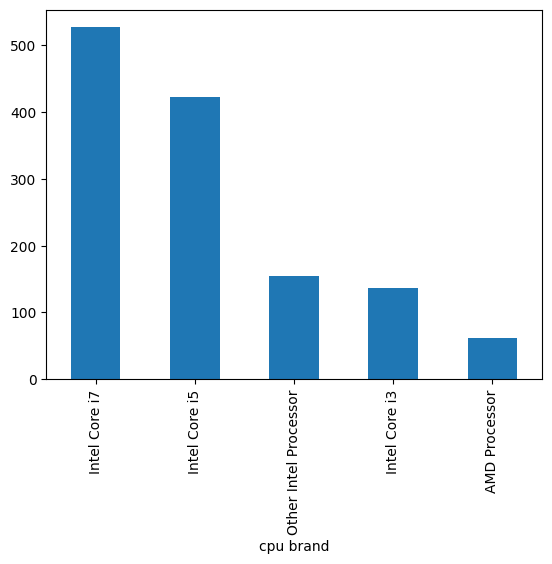

In [71]:
df['cpu brand'].value_counts().plot(kind='bar')

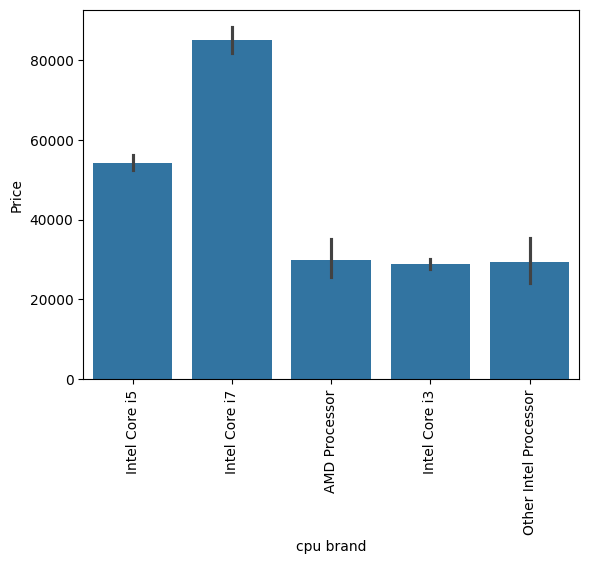

In [72]:
sns.barplot(df,x=df['cpu brand'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

In [73]:
pd.set_option('display.max_columns', None)
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Full HD,TouchScreen,Ultra HD,Retina Display,X_Resolution,Y_resolution,PPI,SSD,HDD,Flash Storage,Hybrid Storage,new cpu,cpu brand
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71379,1,0,0,0,1,2560.0,1600.0,226.983005,128,0,0,0,Intel Core i5,Intel Core i5
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47896,0,0,0,0,0,1440.0,900.0,127.677940,0,0,128,0,Intel Core i5,Intel Core i5
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636,0,1,0,0,0,1920.0,1080.0,141.211998,256,0,0,0,Intel Core i5,Intel Core i5
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195,1,0,0,0,1,2880.0,1800.0,220.534624,512,0,0,0,Intel Core i7,Intel Core i7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96096,1,0,0,0,1,2560.0,1600.0,226.983005,256,0,0,0,Intel Core i5,Intel Core i5


## Column 'Gpu'

In [74]:
df['Gpu'].sample(5)

485    Intel UHD Graphics 620
447        Nvidia Quadro M620
289      Nvidia GeForce 940MX
116    Intel UHD Graphics 620
749      Nvidia Quadro M2000M
Name: Gpu, dtype: object

In [75]:
df['new gpu']=df['Gpu'].apply(lambda x: x.split()[0])

In [76]:
df['new gpu'].value_counts()

new gpu
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [134]:
# drop 'ARM'
df=df[df['new gpu']!='ARM']

<Axes: xlabel='new gpu'>

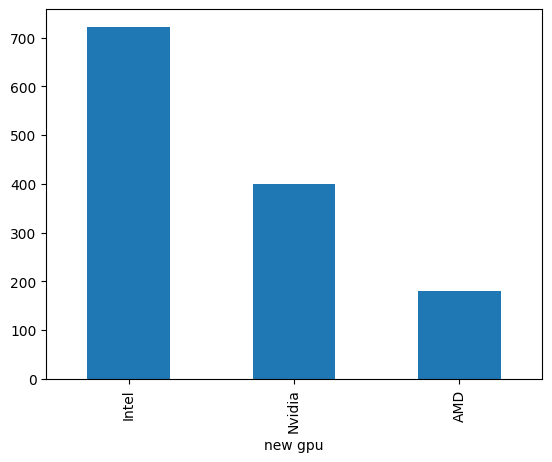

In [78]:
df['new gpu'].value_counts().plot(kind='bar')

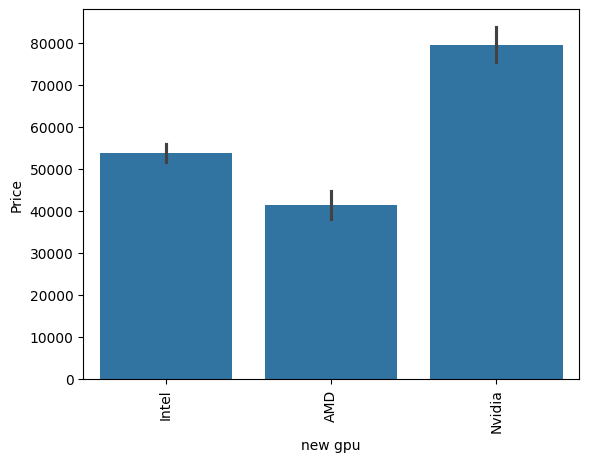

In [79]:
sns.barplot(df,x=df['new gpu'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

## Column 'OpSys'

In [80]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [81]:
def fetch_os(data):
    if data in ['Windows 10','Windows 7','Windows 10 S']:
        return 'Windows'
    elif data in ['macOS','Mac OS X']:
        return 'Mac'
    else:
        return "Other"

In [82]:
df['OS']=df['OpSys'].apply(fetch_os)

In [83]:
df['OS'].value_counts()

OS
Windows    1125
Other       156
Mac          21
Name: count, dtype: int64

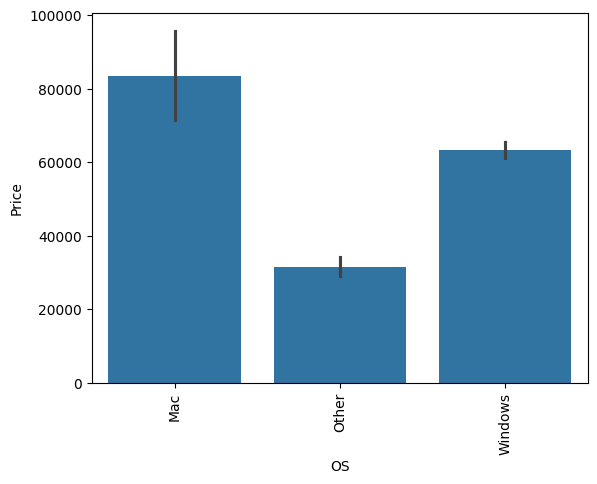

In [84]:
sns.barplot(df,x=df['OS'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

## Column 'Weight'

In [85]:
df['Weight']=df['Weight'].str.replace('kg','').astype(float)

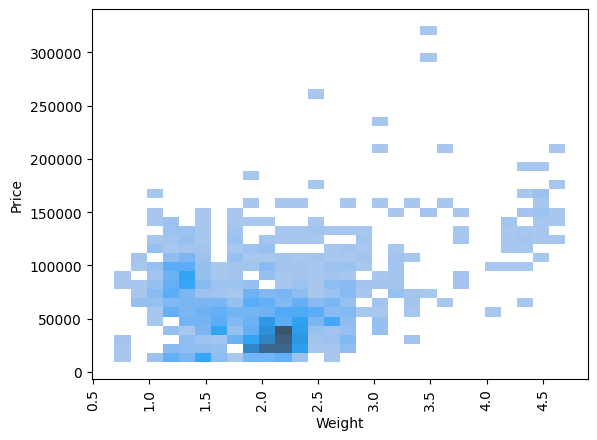

In [86]:
sns.histplot(df,x=df['Weight'],y=df['Price'])
plt.xticks(rotation=90)
plt.show()

In [87]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Full HD,TouchScreen,Ultra HD,Retina Display,X_Resolution,Y_resolution,PPI,SSD,HDD,Flash Storage,Hybrid Storage,new cpu,cpu brand,new gpu,OS
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71379,1,0,0,0,1,2560.0,1600.0,226.983005,128,0,0,0,Intel Core i5,Intel Core i5,Intel,Mac
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47896,0,0,0,0,0,1440.0,900.0,127.677940,0,0,128,0,Intel Core i5,Intel Core i5,Intel,Mac
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636,0,1,0,0,0,1920.0,1080.0,141.211998,256,0,0,0,Intel Core i5,Intel Core i5,Intel,Other
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195,1,0,0,0,1,2880.0,1800.0,220.534624,512,0,0,0,Intel Core i7,Intel Core i7,AMD,Mac
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96096,1,0,0,0,1,2560.0,1600.0,226.983005,256,0,0,0,Intel Core i5,Intel Core i5,Intel,Mac


## Column 'Price'

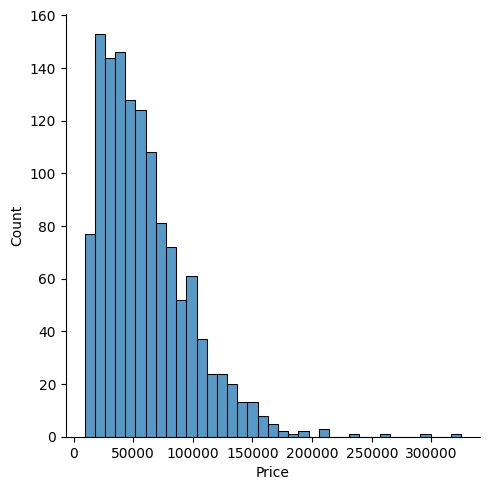

In [88]:
sns.displot(df['Price'])

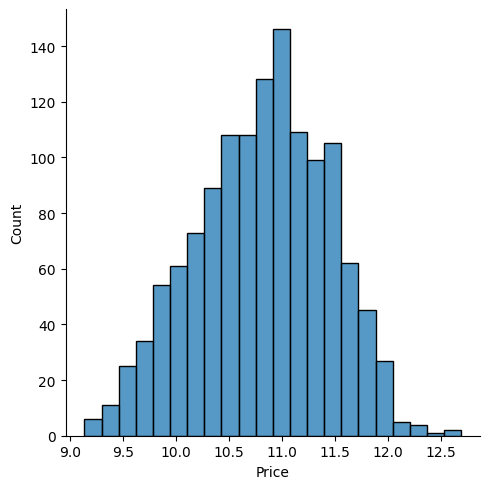

In [89]:
sns.displot(np.log(df['Price']))

In [90]:
df.corr(numeric_only=True)['Price']

Inches            0.067328
Ram               0.742905
Weight            0.209867
Price             1.000000
IPS               0.253320
Full HD           0.198093
TouchScreen       0.192918
Ultra HD          0.343951
Retina Display    0.087852
X_Resolution      0.557370
Y_resolution      0.554592
PPI               0.475369
SSD               0.670660
HDD              -0.096891
Flash Storage    -0.040067
Hybrid Storage    0.007942
Name: Price, dtype: float64

In [91]:
df.head(1)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Full HD,TouchScreen,Ultra HD,Retina Display,X_Resolution,Y_resolution,PPI,SSD,HDD,Flash Storage,Hybrid Storage,new cpu,cpu brand,new gpu,OS
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71379,1,0,0,0,1,2560.0,1600.0,226.983005,128,0,0,0,Intel Core i5,Intel Core i5,Intel,Mac


## store training features in new df. 

In [92]:
train_df=df[['Company','TypeName','Ram','Weight','IPS','Full HD','TouchScreen','Ultra HD','Retina Display','PPI','SSD','HDD','new gpu','cpu brand','OS','Price']]

In [93]:
train_df.shape

(1302, 16)

In [94]:
train_df=train_df.drop(columns=['Retina Display','Ultra HD'])

In [95]:
train_df.corr(numeric_only=True)['Price']

Ram            0.742905
Weight         0.209867
IPS            0.253320
Full HD        0.198093
TouchScreen    0.192918
PPI            0.475369
SSD            0.670660
HDD           -0.096891
Price          1.000000
Name: Price, dtype: float64

In [96]:
train_df.isnull().sum()

Company        0
TypeName       0
Ram            0
Weight         0
IPS            0
Full HD        0
TouchScreen    0
PPI            0
SSD            0
HDD            0
new gpu        0
cpu brand      0
OS             0
Price          0
dtype: int64

# Train Test and split

In [97]:
X=train_df.drop(columns=['Price'])
y=np.log(train_df['Price'])

In [98]:
X.shape,y.shape

((1302, 13), (1302,))

In [99]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=1)

In [100]:
X.head(1)

,Company,TypeName,Ram,Weight,IPS,Full HD,TouchScreen,PPI,SSD,HDD,new gpu,cpu brand,OS
0,Apple,Ultrabook,8,1.37,1,0,0,226.983005,128,0,Intel,Intel Core i5,Mac


In [101]:
# Dealing with catagorical columns 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder

step1=ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'),[0,1,10,11,12])],remainder='passthrough')


In [102]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

In [103]:
R2=[]
MEA=[]

# Linear Regression

In [104]:
from sklearn.linear_model import LinearRegression

In [105]:
step2 = LinearRegression()
pipe = Pipeline([
    ('step1', step1), 
    ('step2', step2)
])

In [106]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('col_tnf',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [0, 1, 10, 11, 12])])),
                ('step2', LinearRegression())])

In [107]:
y_pred = pipe.predict(X_test)

In [108]:
y_pred

array([11.47583402, 10.6618002 , 11.40653389, 10.82530134, 10.65226398,
       10.82508443,  9.87676302, 10.3422327 , 10.05147227, 10.98736203,
       10.94009819, 10.90828121, 11.51662579, 11.29789399, 10.18973309,
       11.29590506, 11.11467015, 10.68180581, 10.97423084, 10.86290229,
       10.90851883, 10.82510057, 11.45949417, 11.22788693, 10.04245284,
       11.12117551, 10.50741579, 10.32421993, 10.88549182, 11.14822665,
       10.09035881, 10.12398055, 10.44037238, 11.07211678, 10.48151965,
       10.56720193, 10.33597771, 10.38915744, 11.00998064, 11.93802871,
       10.98691044, 10.31871566, 10.80096069, 10.76646973, 11.11046711,
       11.48012125, 10.43463997, 11.64002067, 10.90720822, 11.89666448,
        9.61165603, 10.94307911, 10.41555641, 11.3918968 , 11.09020646,
       11.50113755, 11.10155514, 11.10212337, 10.95042977, 10.9271974 ,
       11.16958017, 11.70985389, 11.35698322, 11.55304822, 10.34084873,
       10.63519729, 10.43707294, 11.06013921, 11.16287965, 10.69

In [109]:
R2.append(r2_score(y_test, y_pred))
MEA.append(mean_absolute_error(y_test, y_pred))

In [110]:
R2

[0.7906709540135171]

In [111]:
print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

R2 score: 0.7906709540135171
MAE: 0.2148123223549902


# RandomForestRegressor

In [112]:
from sklearn.ensemble import RandomForestRegressor
step3 = RandomForestRegressor(n_estimators=300,
                              random_state=1,
                              max_samples=0.8,
                              max_features=0.75,
                              max_depth=20)

pipe1 = Pipeline([
    ('step1', step1),
    ('step2', step3)
])

pipe1.fit(X_train, y_train)
y1_pred = pipe1.predict(X_test)
print('R2 score:', r2_score(y_test, y1_pred))
print('MAE:', mean_absolute_error(y_test, y1_pred))


R2 score: 0.8821366677890466
MAE: 0.160668111786389


In [113]:
R2.append(r2_score(y_test, y_pred))
MEA.append(mean_absolute_error(y_test, y_pred))

In [114]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'step2__n_estimators': [200, 300, 500, 800],
    'step2__max_depth': [None, 10, 20, 30, 40],
    'step2__max_features': ['sqrt', 'log2', 0.6, 0.8],
    'step2__min_samples_split': [2, 5, 10],
    'step2__min_samples_leaf': [1, 2, 4],
    'step2__max_samples': [None, 0.6, 0.8]
}

random_search = RandomizedSearchCV(
    pipe1,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

/Users/sabnamgurung/miniforge3/envs/gensim/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/sabnamgurung/miniforge3/envs/gensim/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/sabnamgurung/miniforge3/envs/gensim/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/sabnamgurung/miniforge3/envs/gensim/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  war

Best Parameters: {'step2__n_estimators': 800, 'step2__min_samples_split': 2, 'step2__min_samples_leaf': 1, 'step2__max_samples': None, 'step2__max_features': 'log2', 'step2__max_depth': None}
Best CV Score: 0.8785031814184157


## ExtraTreeRegressor

In [115]:
from sklearn.ensemble import ExtraTreesRegressor

step4 = ExtraTreesRegressor(
    n_estimators=500,
    random_state=1,
    max_depth=25,
    max_features=0.8,
    min_samples_split=2,
    min_samples_leaf=1
)

pipe_et = Pipeline([
    ('step1', step1),
    ('step2', step4)
])

pipe_et.fit(X_train, y_train)
y_pred = pipe_et.predict(X_test)

print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

R2 score: 0.8663873945278795
MAE: 0.1613747016188456


In [116]:
R2.append(r2_score(y_test, y_pred))
MEA.append(mean_absolute_error(y_test, y_pred))

## Gradient Boosting Regressor

In [117]:
from sklearn.ensemble import GradientBoostingRegressor

step5 = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=1
)

pipe_gb = Pipeline([
    ('step1', step1),
    ('step2', step5)
])

pipe_gb.fit(X_train, y_train)
y_pred = pipe_gb.predict(X_test)

print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

R2 score: 0.8961678856330649
MAE: 0.1516112140237873


In [118]:
R2.append(r2_score(y_test, y_pred))
MEA.append(mean_absolute_error(y_test, y_pred))

## AdaBoost Regressor

In [119]:
from sklearn.ensemble import AdaBoostRegressor

step6 = AdaBoostRegressor(
    n_estimators=300,
    learning_rate=0.1,
    random_state=1
)

pipe_ada = Pipeline([
    ('step1', step1),
    ('step2', step6)
])

pipe_ada.fit(X_train, y_train)
y_pred = pipe_ada.predict(X_test)

print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

R2 score: 0.7982060465829783
MAE: 0.22044372129159215


In [120]:
R2.append(r2_score(y_test, y_pred))
MEA.append(mean_absolute_error(y_test, y_pred))

## Hist Gradient Boosting REgressor

In [121]:
from sklearn.ensemble import HistGradientBoostingRegressor

step7 = HistGradientBoostingRegressor(
    max_depth=10,
    learning_rate=0.05,
    max_iter=500,
    random_state=1
)

pipe_hgb = Pipeline([
    ('step1', step1),
    ('step2', step7)
])

pipe_hgb.fit(X_train, y_train)
y_pred = pipe_hgb.predict(X_test)

print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

R2 score: 0.8902212755466175
MAE: 0.14915899169259864


In [122]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'step2__learning_rate': [0.01, 0.05, 0.1],
    'step2__max_depth': [5, 10, None],
    'step2__max_iter': [300, 500, 800]
}

random = RandomizedSearchCV(
    pipe_hgb,
    param_grid,
    cv=5,
    scoring='r2',
    n_iter=10,
    random_state=1
)

random.fit(X_train, y_train)

print("Best Params:", random.best_params_)
print("Best Score:", random.best_score_)

/Users/sabnamgurung/miniforge3/envs/gensim/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/sabnamgurung/miniforge3/envs/gensim/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/sabnamgurung/miniforge3/envs/gensim/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/sabnamgurung/miniforge3/envs/gensim/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  war

Best Params: {'step2__max_iter': 800, 'step2__max_depth': 5, 'step2__learning_rate': 0.1}
Best Score: 0.8728864960704383


In [123]:
R2.append(r2_score(y_test, y_pred))
MEA.append(mean_absolute_error(y_test, y_pred))

In [124]:
R2

[0.7906709540135171,
 0.7906709540135171,
 0.8663873945278795,
 0.8961678856330649,
 0.7982060465829783,
 0.8902212755466175]

In [125]:
MEA

[0.2148123223549902,
 0.2148123223549902,
 0.1613747016188456,
 0.1516112140237873,
 0.22044372129159215,
 0.14915899169259864]

In [126]:
Name=['Linear Regression','Random Forest','Extra Tree','Gradient Boosting Regresson','AdaBoost Regressor','HistGradient Boosting Regressor']

In [127]:
alg_com = pd.DataFrame({
    'Algorithm': Name,
    'R2 Score': R2,
    'MAE': MEA
})

alg_com

,Algorithm,R2 Score,MAE
0,Linear Regression,0.790671,0.214812
1,Random Forest,0.790671,0.214812
2,Extra Tree,0.866387,0.161375
3,Gradient Boosting Regresson,0.896168,0.151611
4,AdaBoost Regressor,0.798206,0.220444
5,HistGradient Boosting Regressor,0.890221,0.149159


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Linear Regression'),
  Text(1, 0, 'Random Forest'),
  Text(2, 0, 'Extra Tree'),
  Text(3, 0, 'Gradient Boosting Regresson'),
  Text(4, 0, 'AdaBoost Regressor'),
  Text(5, 0, 'HistGradient Boosting Regressor')])

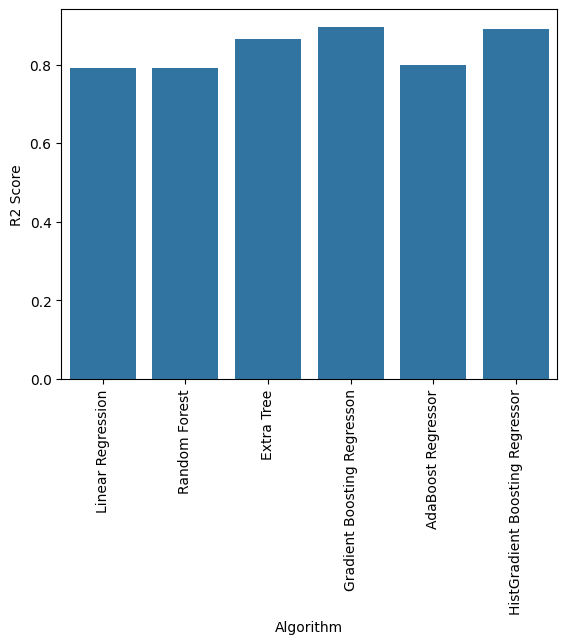

In [128]:
sns.barplot(alg_com,x=alg_com['Algorithm'],y=alg_com['R2 Score'])
plt.xticks(rotation='vertical')

# Export HistGradient


In [129]:
import pickle as pkl

In [130]:
pkl.dump(pipe_hgb,open('pipe.pkl','wb' ))
pkl.dump(train_df,open('df.pkl','wb'))

In [131]:
a=pkl.load(open('df.pkl','rb'))

In [132]:
a

,Company,TypeName,Ram,Weight,IPS,Full HD,TouchScreen,PPI,SSD,HDD,new gpu,cpu brand,OS,Price
0,Apple,Ultrabook,8,1.37,1,0,0,226.983005,128,0,Intel,Intel Core i5,Mac,71379
1,Apple,Ultrabook,8,1.34,0,0,0,127.677940,0,0,Intel,Intel Core i5,Mac,47896
2,HP,Notebook,8,1.86,0,1,0,141.211998,256,0,Intel,Intel Core i5,Other,30636
3,Apple,Ultrabook,16,1.83,1,0,0,220.534624,512,0,AMD,Intel Core i7,Mac,135195
4,Apple,Ultrabook,8,1.37,1,0,0,226.983005,256,0,Intel,Intel Core i5,Mac,96096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,1.80,1,1,1,157.350512,128,0,Intel,Intel Core i7,Windows,33993
1299,Lenovo,2 in 1 Convertible,16,1.30,1,0,1,276.053530,512,0,Intel,Intel Core i7,Windows,79867
1300,Lenovo,Notebook,2,1.50,0,0,0,111.935204,0,0,Intel,Other Intel Processor,Windows,12201
1301,HP,Notebook,6,2.19,0,0,0,100.454670,0,1000,AMD,Intel Core i7,Windows,40706
